# Retail Loyalty Product — Analytics + Incrementality Experiment (X5 RetailHero)

**Dataset.** X5 RetailHero uplift dataset — a real randomized loyalty campaign from a large grocery retailer, loaded via `sklift.datasets.fetch_x5()`. Three raw tables joined on `client_id`:

| Table | Rows | What |
|---|---|---|
| `train` | ~200K | experiment customers, with `treatment_flg` (got the communication) + `target` (purchased afterward) |
| `clients` | ~400K | client info (age, gender, signup dates) |
| `purchases` | **~45.8M** | every transaction line **prior to the communication** |

The data is raw transaction logs, not a pre-aggregated table. Loaded via `sklift.datasets.fetch_x5()`, cached locally in `./data/` (~640 MB, downloaded once).

**Question.** *What state is this loyalty product in (metrics, retention, segments)? Did the campaign actually cause more purchases — and if so, who should we target to get the most incremental lift per dollar?*

### Pipeline

| Step | What | Approach |
|---|---|---|
| 1 | Load 3 raw tables | raw-log ingestion + cache |
| 2 | SQL aggregation: 45.8M rows → 1 feature row / customer | DuckDB CTEs, leakage-safe feature engineering |
| 3 | Core metrics + cohort retention + RFM segments | product analytics |
| 4 | Experiment hygiene: SRM + covariate balance (SMD) | experiment validity checks |
| 5 | ATE + regression-adjusted variance reduction (CUPED-style) | causal inference |
| 6 | Heterogeneous effects (uplift / CATE): S- & T-learners | meta-learner uplift models |
| 7 | Score-based targeting: rank customers by predicted incremental effect | decile validation |
| 8 | Targeting policy + business guardrails | score → decision |
| 9 | Monitoring: PSI drift + feedback-loop plan | productionization |

All code cells call functions from `pipeline.py`; inline code in this notebook is limited to visualization glue.

## Setup

Functions are imported from `pipeline.py`, so the notebook and the script stay in sync.

**`SAMPLE_FRAC`** controls speed vs. realism. It keeps a random fraction of *customers* (and only their transactions), so every step runs end-to-end either way:
- `SAMPLE_FRAC = 0.3` → ~60K customers / ~6.8M transactions — **the numbers shown below** (fast default; 50% also fits in ~2.7GB but is slower, and the full 45.8M-row aggregation OOMs an 8GB laptop, see the scale note in Step 6)
- `SAMPLE_FRAC = 0.1` → ~20K customers / ~2M transactions (~30s, even faster while iterating; uplift signal is noisier on a smaller subset)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pipeline

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

SAMPLE_FRAC = 0.3   # 30% of customers; fetch_x5 loads all 45.8M rows into memory and full-data DuckDB aggregation OOMs an 8GB laptop
SEED = 42
print(f"SAMPLE_FRAC = {SAMPLE_FRAC}")

SAMPLE_FRAC = 0.3


## Understand the product

### Step 1 · Load the three raw tables

X5 hands us raw logs, not a tidy feature table. `step1_load` downloads + caches the data, attaches `treatment_flg` / `target` onto `train`, and (in sample mode) subsamples at the **customer** level so per-customer aggregates stay consistent.

In [2]:
# Downloads and caches the X5 dataset (~640 MB, first run only), then samples
# SAMPLE_FRAC of customers and keeps only their transactions — so every
# per-customer aggregate is consistent across all three tables.
train, clients, purchases = pipeline.step1_load(sample_frac=SAMPLE_FRAC, seed=SEED)

print("\ntrain (experiment customers):")
display(train.head(3))
print("clients (demographics):")
display(clients.head(3))
print("purchases (raw transaction lines, pre-communication):")
display(purchases.head(3))

[load] train=60,012  clients=400,162  purchases=6,843,173  (sample_frac=0.3)

train (experiment customers):


,client_id,target,treatment_flg
0,ac126a8be6,0,0
1,ba4a67aba7,1,0
2,b2fc4ea450,0,0


clients (demographics):


,client_id,first_issue_date,first_redeem_date,age,gender
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,000048b7a6,2018-12-15 13:33:11,NaN,68,F


purchases (raw transaction lines, pre-communication):


,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,9a80204f78,2.0,80.0,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,da89ebd374,1.0,65.0,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,0a95e1151d,1.0,24.0,NaN


### Step 2 · SQL aggregation layer — 45.8M rows → one feature row per customer

This is the heavy lifting, done in **SQL (DuckDB)** the way it would happen against a warehouse. CTEs roll *product lines → transactions → customers*, producing RFM-style and behavioral features (spend, basket size, breadth of products/stores, loyalty points, recency, tenure).

**Leakage guard:** every purchase here is *prior to the communication*, so each aggregate is a legitimate pre-treatment covariate — no post-treatment signal leaks in.

In [3]:
# DuckDB CTEs roll product lines → transactions → customers.
# Output: one row per customer, 23 features covering spend, basket size,
# loyalty-point behaviour, store breadth, recency, tenure, demographics.
# All aggregates are over pre-communication purchases only — no leakage.
df, feature_names = pipeline.step2_features_sql(train, clients, purchases)

print(f"\nfeature columns ({len(feature_names)}): {feature_names}")
display(df.head(3))

[features] customers=60,012  n_features=23 (built in SQL)

feature columns (23): ['n_tx', 'spend_total', 'spend_mean', 'spend_std', 'basket_mean', 'pts_received', 'pts_spent', 'exp_pts_received', 'exp_pts_spent', 'sum_from_iss_mean', 'sum_from_red_mean', 'n_products', 'n_stores', 'recency_days', 'tenure_days', 'age', 'issue_tenure_days', 'has_redeemed', 'redeem_recency_days', 'issue_to_redeem_days', 'gender_M', 'gender_U', 'gender_nan']


,client_id,target,treatment_flg,n_tx,spend_total,spend_mean,spend_std,basket_mean,pts_received,pts_spent,exp_pts_received,exp_pts_spent,sum_from_iss_mean,sum_from_red_mean,n_products,n_stores,recency_days,tenure_days,age,issue_tenure_days,has_redeemed,redeem_recency_days,issue_to_redeem_days,gender_M,gender_U,gender_nan
0,000012768d,1,0,4,2803.00,700.750000,258.000484,13.000000,25.7,0.0,0.0,0.0,136.000000,NaN,46,3,4,103,45,590,1.0,438.0,152.0,False,True,False
1,00020e7b18,1,1,18,25819.61,1434.422778,1008.952394,15.111111,286.1,-592.0,0.0,-30.0,243.333333,306.4,175,4,3,112,73,476,1.0,432.0,44.0,False,True,False
2,00022fd34f,1,1,33,6852.51,207.651818,181.406950,3.515152,67.0,-48.0,0.0,0.0,107.969697,65.0,69,2,2,112,65,458,1.0,314.0,144.0,False,True,False


### Step 3 · Product analytics — metrics, cohort retention, RFM segments

Three product-analytics views computed from pre-experiment history:
1. **Core metrics** — frequency, monetary, recency, and purchase rate (a North-Star candidate for a loyalty product).
2. **Acquisition-cohort retention** — group customers by first-purchase month, track how many stay active *m* months later (SQL).
3. **RFM segmentation** — SQL `NTILE` quintiles on Recency / Frequency / Monetary → `champions` / `at_risk` / `mid`. This `rfm_segment` column feeds a guardrail later (are we targeting already-loyal customers who would buy anyway?).

[analytics] core product metrics: {'customers': 60012, 'avg_purchase_frequency': 20.1, 'avg_monetary_per_customer': 8551.32, 'median_recency_days': 4.0}
[analytics] cohort retention (rows=cohort, cols=months since first buy):
month_offset    0     1     2     3     4
cohort                                   
2018-11-01    1.0  0.96  0.93  0.95  0.96
2018-12-01    1.0  0.83  0.88  0.93   NaN
2019-01-01    1.0  0.86  0.92   NaN   NaN
2019-02-01    1.0  0.87   NaN   NaN   NaN
2019-03-01    1.0   NaN   NaN   NaN   NaN
[analytics] RFM segments: {'mid': 29983, 'at_risk': 15027, 'champions': 15002}


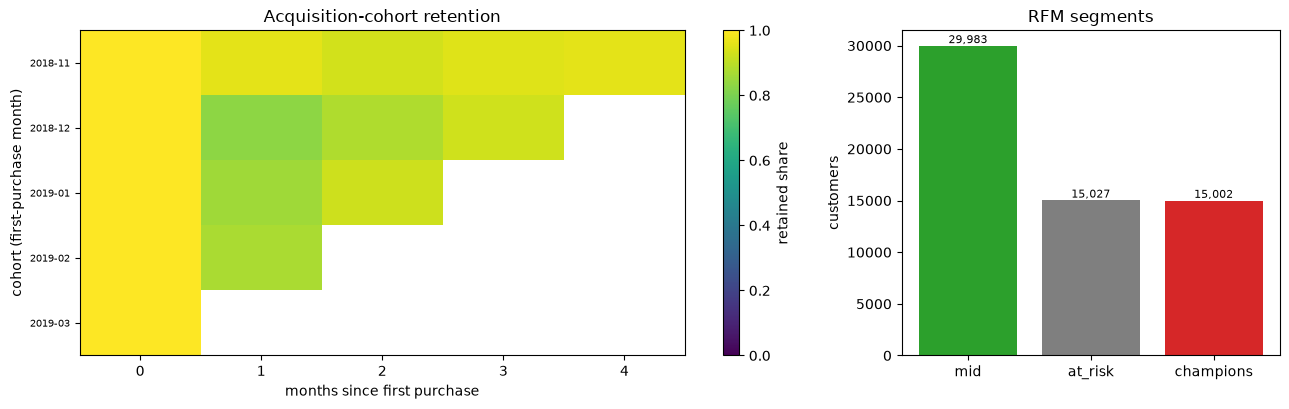

In [4]:
# Three views over pre-experiment history:
#   (1) core product metrics — avg frequency, monetary, recency, purchase rate
#   (2) acquisition-cohort retention — SQL monthly retention grid per join cohort
#   (3) RFM segmentation — SQL NTILE quintiles → champions / at_risk / mid
# Returns df with rfm_segment column (used as a guardrail in step 8) and the
# retention pivot table for the heatmap below.
df, retention = pipeline.step3_product_analytics(df, purchases)
pipeline.step3_charts(df, retention)
plt.show()

## Experiment on the product

### Step 4 · Experiment hygiene

Before trusting any effect estimate, two standard gates:
- **SRM (sample-ratio mismatch)** — chi-square of realized treat/control counts vs the intended ratio. Catches pipeline/instrumentation bugs.
- **Covariate balance (SMD)** — standardized mean difference per engineered feature. In a clean randomized experiment, most should sit below |0.1|.

In [5]:
# Two validity checks before trusting any effect estimate:
#   SRM  — chi-square of realized treat/control counts vs 50/50; catches
#           pipeline or instrumentation bugs that corrupt the randomization.
#   SMD  — standardized mean difference per feature; should be |SMD| < 0.1
#           in a clean randomized experiment (confirms groups are comparable).
# Also prints the achievable MDE at the actual sample size.
pipeline.step4_validate(df, feature_names)

[design] H0: rate_treat == rate_control | Ha: != (two-sided, alpha=0.05, power=0.80)
[design] baseline(hist 7d pre-period)=0.6761  n/arm=29,876  achievable MDE=+0.0107pp (designed for +0.01pp)
[split] treat=30,136 (0.502)  control=29,876 (0.498)
[srm] chi-square vs 50/50: chi2=1.13  p=0.289 (OK)
[balance] largest |SMD|: [('has_redeemed', np.float64(0.023)), ('exp_pts_received', np.float64(0.022)), ('n_tx', np.float64(0.012)), ('spend_std', np.float64(0.01)), ('redeem_recency_days', np.float64(-0.009))]
[rates] target: control=0.6007  treat=0.6367  diff=0.0360


### Step 5 · Average treatment effect (ATE) + variance reduction

Estimates of the campaign's average lift, from simple to variance-reduced — each with its own significance test:
1. **Naive** — simple treated-minus-control difference in purchase rate, with a 95% CI, plus the textbook **two-proportion z-test** (which uses a *pooled-variance* null, so it's only asymptotically equivalent to the unpooled CI).
2. **CUPED** — variance reduction from a *single* pre-experiment covariate (bought in the 7 days before the experiment, same window as `target`): `Y_cuped = Y − θ(X − E[X])`, `θ = Cov(Y,X)/Var(X)`. Under randomization the point estimate is unchanged and the SE shrinks; reported with z/p.
3. **Regression-adjusted (ANCOVA)** — OLS with *multiple* pre-treatment covariates; the treatment coefficient is the adjusted ATE, usually with an **even smaller standard error** — i.e., the same precision from less sample. **CUPED is its single-covariate special case.** Here the p-value and CI come off the *same* SE, so they're exactly equivalent.
4. **Secondary + guardrails** — ATE split by RFM segment (descriptive, does *not* gate launch on its own), plus population-level do-no-harm guardrails: **G1** no segment is significantly hurt; **G2** `champions` (who'd likely buy anyway) aren't the main *source* of the lift.
5. **Decision** — judged on **one pre-specified primary estimator (ANCOVA)**, not whichever readout happens to be significant (that would be p-hacking). Primary passing (statistical **and** practical significance, effect ≥ MDE) is only *necessary*: **LAUNCH requires primary AND every guardrail to pass** — otherwise HOLD.

In [6]:
# Three ATE estimators, each more variance-efficient than the last:
#   naive     — simple treated-minus-control difference + z-test
#   CUPED     — subtracts the linear projection of one pre-treatment covariate
#               (recent purchase activity); same point estimate, smaller SE
#   ANCOVA    — OLS on all pre-treatment features; the primary estimator,
#               typically the tightest SE (CUPED is its one-covariate special case)
# Returns a dict of estimates, SEs, p-values, and guardrail pass/fail flags.
# Primary decision: ANCOVA must pass stat + practical significance AND all
# guardrails (no segment harmed; champions not the main source of lift).
ate = pipeline.step5_ate(df, feature_names)
ate

[baseline] purchase rate (control) = 0.6007
[ate] naive  = 0.03600  95% CI [0.02823, 0.04376]  SE=0.00396
[test] two-proportion z=9.078  p=1.103e-19  (reject H0 @ alpha=0.05)
[ate] cuped  = 0.03438  SE=0.00380  z=9.049  p=1.438e-19  (SE reduced 4.1%, theta=0.295)
[ate] adjusted = 0.03392  SE=0.00359  p=3.027e-21  95% CI [0.02690, 0.04095]  (SE reduced 9.5%)
[efficiency] regression adjustment reaches the naive precision with ~18% less sample (same MDE & power)
[primary] ANCOVA  stat_sig=True  practical(>=+1%)=True  ->  OK (necessary, pending guardrails)
[secondary] ATE by RFM segment (descriptive, does not gate launch):
[secondary]   champions  n=15,002  ate=+0.0205  95% CI [+0.0103, +0.0307]
[secondary]   at_risk    n=15,027  ate=+0.0475  95% CI [+0.0324, +0.0626]
[secondary]   mid        n=29,983  ate=+0.0341  95% CI [+0.0232, +0.0451]
[guardrail G1] do-no-harm: harmed segments = none -> PASS
[guardrail G2] champions incremental share = 0.15 (> 35% = cannibalizing loyalty) -> PASS
[de

{'ate': np.float64(0.035996982377172304),
 'se': np.float64(0.0039628154019993094),
 'pval': np.float64(1.10269341795523e-19),
 'cuped_ate': np.float64(0.03438329444045263),
 'cuped_se': np.float64(0.003799521472081863),
 'cuped_p': np.float64(1.4378903214050243e-19),
 'adj_ate': np.float64(0.03392451085857381),
 'adj_se': np.float64(0.0035854216814862646),
 'adj_p': np.float64(3.0271292503732595e-21),
 'se_reduction': np.float64(0.0952337371866081),
 'sample_saving': np.float64(0.18139800967468822),
 'stat_sig': True,
 'practical': np.True_,
 'primary_pass': np.True_,
 'g1_pass': True,
 'g2_pass': True,
 'champions_incr_share': np.float64(0.15040770070569803),
 'launch': True}

### Step 6 · Heterogeneous treatment effects (uplift / CATE)

The average effect hides *who* responds. Uplift is inherently counterfactual (we never observe both treated and untreated outcomes for one person), so the per-customer effect is modeled. Two meta-learners (sharing one base estimator, so the only variable is the approach) score per-customer incremental effect on a held-out test set:
- **S-learner** (`SoloModel`) — one model with treatment as a feature.
- **T-learner** (`TwoModels`) — separate treated/control models, differenced.

**Feature engineering drove the performance gain.** Rather than swap models blindly, I ran `{S, T} × {base features, enriched features}` on a fixed depth-3 base estimator to isolate what actually moves quality:

| feature set (same depth-3 LGBM base) | S-learner uplift@30% | T-learner uplift@30% |
|---|---|---|
| base (16 features) | ~0.059 | ~0.060 |
| **enriched (23 features)** | **~0.082** | **~0.064** |

Adding domain-derived loyalty signals (first-redeem/issue timing, express points, `trn_sum_from_red`) improved uplift@30% by ~37% for the S-learner and ~7% for the T-learner — confirming that **feature engineering is the primary lever, not meta-learner choice**. The T-learner is pre-specified as the primary for Step 8 (chosen a priori, not by picking whichever won on the test set).

Base estimator is `LGBMClassifier(max_depth=3)` — shallow to avoid overfitting on a weak signal, and handles feature-engineering NaNs natively.

> **Scale note:** the numbers here are on a 30% customer sample (`SAMPLE_FRAC = 0.3`). The pipeline is fully deterministic (single-threaded DuckDB + `client_id` sort + LightGBM `deterministic`), so `pipeline.py` and this notebook return identical numbers.

In [13]:
# Trains S-learner and T-learner on the training split, evaluates on a
# held-out test set (stratified by treatment arm).
# Returns dict u with:
#   y_te, t_te          — held-out labels and treatment flags
#   s_scores, t_scores  — per-customer predicted incremental effect (CATE)
#                         from each meta-learner; higher = more likely to
#                         respond incrementally to the treatment
u = pipeline.step6_uplift(df, feature_names)

### Step 7 · Score-based targeting: ranking customers by predicted incremental effect

Each customer is scored with a predicted incremental effect (T-learner). This ranking guides budget-constrained targeting: when the campaign can't reach everyone, send to the highest-scoring customers first.

To validate the ranking, we split the holdout set into 10 equal bands by predicted score and compare treated vs. control conversion rates per band. The key question: is observed lift actually concentrated at the top?

             n   treat  control  uplift_pp
decile                                    
D9      1801.0  0.6087   0.5169       9.18
D8      1800.0  0.6137   0.5358       7.79
D7      1800.0  0.6193   0.5982       2.11
D6      1801.0  0.6558   0.6180       3.78
D5      1800.0  0.6925   0.6523       4.02
D4      1800.0  0.7387   0.6968       4.19
D3      1801.0  0.7380   0.6949       4.30
D2      1800.0  0.6570   0.6330       2.40
D1      1800.0  0.5629   0.5091       5.38
D0      1801.0  0.5142   0.4793       3.48

[ranking check] top-20% (D8-D9) mean uplift +8.49pp vs overall +4.66pp  ->  1.8x
note: lift is concentrated in the top ~20%; middle deciles are flat/noisy (consistent with the small Qini) - an honest weak-HTE result
[eval] saved decile_validation.png


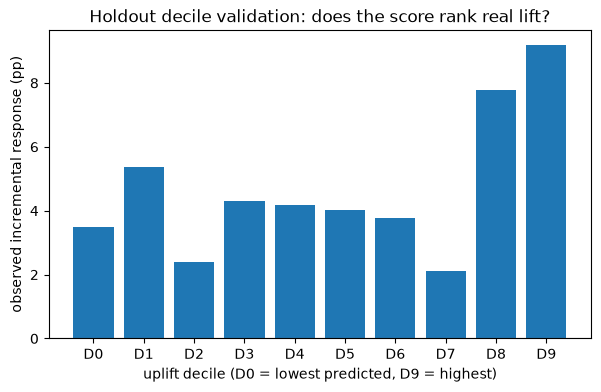

In [8]:
# Cuts the holdout set into 10 equal bands by predicted T-learner score.
# For each band: compares treated vs control conversion rates and computes
# observed incremental response (pp). If the model ranks customers correctly,
# the top deciles (D8-D9) should show the highest observed lift.
# Prints decile table + "top-20% vs overall" concentration ratio.
# Saves decile_validation.png.
dec = pipeline.step7b_decile(u)
plt.show()

### Step 8 · Targeting policy + business guardrails

Turn scores into a decision: **treat only the top-k% by predicted uplift**, then check it actually pays off and doesn't misfire.
- **Guardrail 1 (do no harm / separates):** targeted uplift should be positive and clearly above the non-targeted group.
- **Guardrail 2 (no loyalty cannibalization):** we shouldn't be *only* hitting already-loyal `champions`, who'd likely buy anyway (low incrementality, wasted spend).

In [9]:
# Applies a top-k% targeting policy: treat only the customers with the
# highest predicted incremental effect (T-learner score).
# Reports:
#   - measured uplift in the targeted vs non-targeted group (separation check)
#   - % of total incremental responses captured vs % of budget spent
#   - guardrail: champions share in targeted set vs population
#     (are we just re-targeting already-loyal customers?)
pipeline.step8_policy(u, k_percent=0.30)

[policy] targeting top 30% (cutoff uplift=0.05142), 5401 customers
[policy] measured uplift  targeted=0.06363  non-targeted=0.04194  (separation 1.5x)
[policy][value] treating top 30% captures ~39% of the incremental responses of treating all, at 30% of the send cost (~70% spend saved)
[policy][guardrail] champions share in targeted set = 0.14 vs 0.25 population -> OK (not over-targeting already-loyal customers)


{'k_percent': 0.3,
 'uplift_top': 0.06363140145182544,
 'uplift_rest': 0.041944897869448994,
 'captured': np.float64(0.39398295193028526),
 'champions_share': 0.136826513608591}

### Step 9 · Productionization — drift monitoring + feedback loop

What it takes to *run* this targeting model, not just fit it once:
- **Drift** — monitor **PSI** on the uplift-score (and key features); a sustained PSI > ~0.25 means the policy was tuned on a stale distribution → re-estimate.
- **Selective labels / feedback loop** — once we only treat the top-k%, future logs carry treated-tail outcomes only, so the model trains on data its own policy shaped. Mitigation: keep a small **epsilon randomized control** every cycle so unbiased treated/control outcomes keep flowing. The step prints an **epsilon-greedy** sketch — an `explore` slice (its own mini A/B, unbiased across the whole score range) alongside the `exploit` top-30% policy — showing exactly how those unbiased labels are collected.

In [10]:
# Two productionization concerns:
#   PSI drift  — Population Stability Index on the uplift score distribution
#                between a reference period and a recent period.
#                PSI > 0.25 signals the model was tuned on a stale distribution
#                and needs re-estimation.
#   Selective-labels / feedback loop — once we only treat the top-k%, future
#                logs carry treated-tail outcomes only. Mitigation: keep a small
#                epsilon randomized control every cycle (explore slice) so
#                unbiased treated/control outcomes keep flowing.
#                Prints an epsilon-greedy bucket breakdown (exploit vs explore).
pipeline.step9_monitoring(u)

[monitor] uplift-score PSI (ref vs recent) = 0.002 -> OK
[monitor] feedback-loop guard: keep an epsilon randomized control each cycle so unbiased outcomes keep flowing (selective-labels fix).
[monitor] epsilon-greedy buckets = {'exploit_skip': 11963, 'exploit_treat': 5127, 'explore_control': 493, 'explore_treat': 421}
[monitor] explore (unbiased randomized control) = 914 (5.1%); rest served by the model's top-30% policy.


## Results and findings

- **Product health (steps 1–3)** — defined core metrics, measured acquisition-cohort retention, and segmented customers (RFM). Heavy aggregation (~45.8M rows → 1 row/customer) in SQL (DuckDB), leakage-safe by construction.
- **Campaign effect (steps 4–5)** — passed SRM and SMD checks; ANCOVA-adjusted ATE is statistically and practically significant (p < 1e-19); all guardrails pass → **LAUNCH**.
- **Who to target (steps 6–7)** — feature engineering improved uplift@30% by ~37%. Decile validation confirms lift is concentrated in the top-scoring bands: focusing the campaign on the top 20% delivers the best incremental-response-per-dollar.
- **Targeting policy (step 8)** — sending to the top 30% by predicted score captures ~39% of total incremental responses at 30% of the send cost. Champions guardrail passes (not over-targeting already-loyal customers).
- **Productionization (step 9)** — PSI monitors score drift; epsilon-greedy control slice keeps unbiased labels flowing to prevent feedback-loop degradation.

> **Reproducibility:** results are from a 30% customer sample (`SAMPLE_FRAC = 0.3`). Run end-to-end: `python pipeline.py`.